<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Semanal Nº0: Primeros pasos en la simulación
#### Ivana Rocio Miranda


# Introducción
El principal objetivo de este trabajo fue familiarizarnos con las herramientas a utilizar en la materia. Para comenzar, se desarrolló un generador de señales senoidales utilizando Python, simulando señales básicas que fueron utilizadas en análisis posteriores dentro del procesamiento digital de señales.

Las señales senoidales son fundamentales en el análisis de señales, ya que representan fenómenos periódicos presentes en sistemas físicos, como el sonido o las ondas electromagnéticas.

Una señal senoidal es una oscilación periódica descripta por la ecuación:

$$x(t) = V_{DC} + V_{max} \cdot \sin(2\pi f t + \varphi)$$

Donde cada parámetro tiene un significado físico concreto:

| Parámetro | Símbolo | Unidad | Descripción |
|-----------|---------|--------|-------------|
| Amplitud máxima | $V_{max}$ | Volts | Valor pico de la oscilación |
| Valor medio (offset DC) | $V_{DC}$ | Volts | Desplazamiento vertical de la señal |
| Frecuencia | $f$ | Hz | Cantidad de ciclos por segundo |
| Fase inicial | $\varphi$ | Radianes | Desplazamiento horizontal de la señal |
| Tiempo | $t$ | Segundos | Variable independiente continua |

### Muestreo y el ADC

En la realidad, las señales son continuas en el tiempo, pero las computadoras solo pueden procesar valores discretos. El componente que realiza esta conversión se llama ADC (Analog-to-Digital Converter).

El ADC toma muestras de la señal a intervalos regulares definidos por la frecuencia de muestreo $f_s$:

$$T_s = \frac{1}{f_s}$$

donde $T_s$ es el período de muestreo (tiempo entre muestra y muestra).

El vector de tiempos discreto queda entonces:

$$t[n] = n \cdot T_s, \quad n = 0, 1, 2, \ldots, N-1$$

### Teorema de Nyquist-Shannon

Para que la señal muestreada represente fielmente a la señal original, es obligatorio que:

$$f_s > 2 \cdot f$$

Si esta condición no se cumple, ocurre el aliasing: la señal reconstruida tiene una frecuencia distinta a la original y la información se pierde.

## Defino: `mi_funcion_sen`

La función recibe los 6 parámetros de la señal y devuelve dos vectores de $N \times 1$:
- `tt`: vector de tiempos
- `xx`: muestras de la señal senoidal

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs                                    # período de muestreo
    tt = np.arange(nn) * ts                      # vector de tiempo (N muestras)
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)  # señal senoidal
    
    return tt, xx

Luego, para poder graficar una señal ejemplo, se definieron los parámetros necesarios y se llamó a la función que genera la señal senoidal.

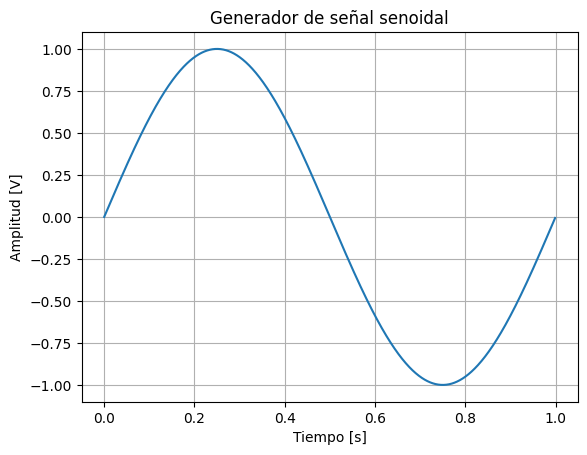

In [11]:

# Parámetros
N = 1000
fs = 1000

# Llamada a la función
tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs)

# Gráfico
plt.figure()
plt.plot(tt, xx)
plt.title("Generador de señal senoidal")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.show()

## Experimentos con aliasing

Usamos `fs = 1000 Hz` y `N = 1000` muestras. La frecuencia de Nyquist es $f_N = f_s/2 = 500$ Hz.

Vamos a observar qué ocurre con las siguientes frecuencias:

| Frecuencia | Relación con Nyquist | Resultado esperado |
|------------|---------------------|--------------------|
| `ff = 500 Hz` | Exactamente en el límite | Señal en el borde, apenas representable |
| `ff = 999 Hz` | Justo antes del límite ($f_s - 1$) | Aliasing: se ve como 1 Hz invertida|
| `ff = 1001 Hz` | Supera Nyquist por poco | Aliasing: se ve como 1 Hz |
| `ff = 2001 Hz` | Supera ampliamente ($2f_s + 1$) | Aliasing: se ve como 1 Hz |

**¿Por qué 999, 1001 y 2001 Hz producen la misma señal aparente?**  
En tiempo discreto, las frecuencias se "pliegan" alrededor de $f_s/2$. Una señal de $f_s - f$ Hz se vuelve indistinguible de una señal de $f$ Hz. Esto es el aliasing o *frequency folding*.


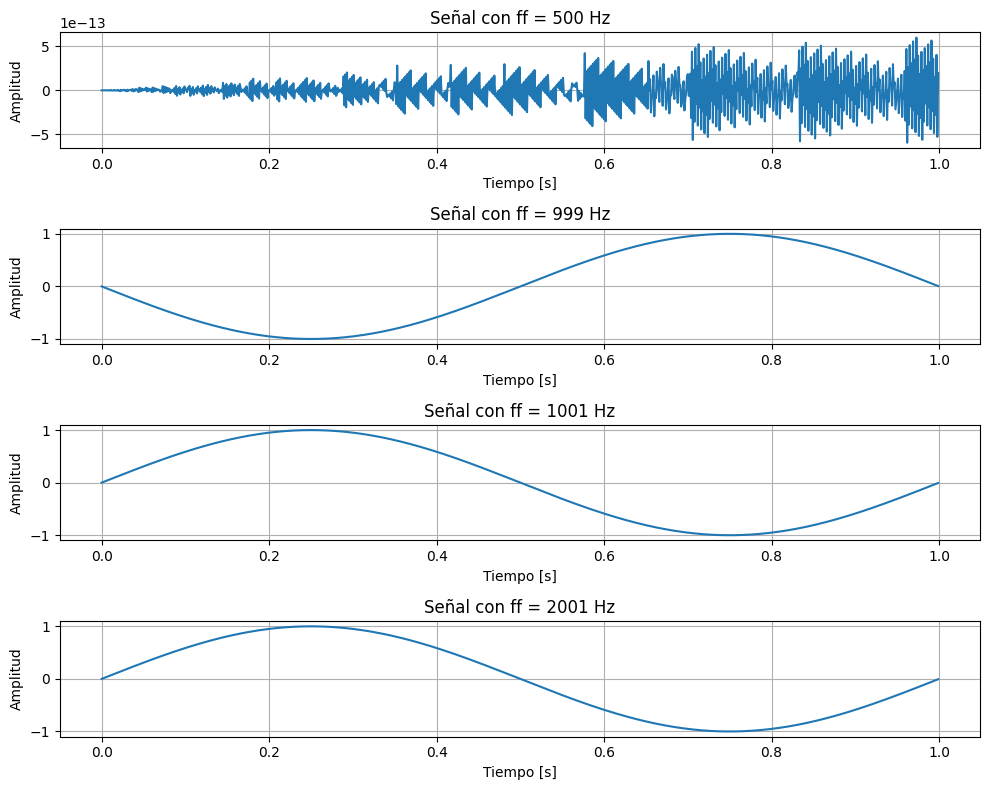

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx

# Parámetros
fs = 1000
N = 1000

frecuencias = [500, 999, 1001, 2001]

plt.figure(figsize=(10,8))

for i, ff in enumerate(frecuencias):
    tt, xx = mi_funcion_sen(1, 0, ff, 0, N, fs)
    
    plt.subplot(4,1,i+1)
    plt.plot(tt, xx)
    plt.title(f"Señal con ff = {ff} Hz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Señal cuadrada propia de un generador de señales

A diferencia de la señal senoidal, la señal cuadrada presenta cambios bruscos entre sus valores máximos y mínimos, sin transiciones suaves. Esto implica que contiene múltiples componentes en frecuencia (armónicos), mientras que la senoidal posee una única frecuencia. Como resultado, la señal cuadrada es más compleja y no es una función continua derivable en todos sus puntos.

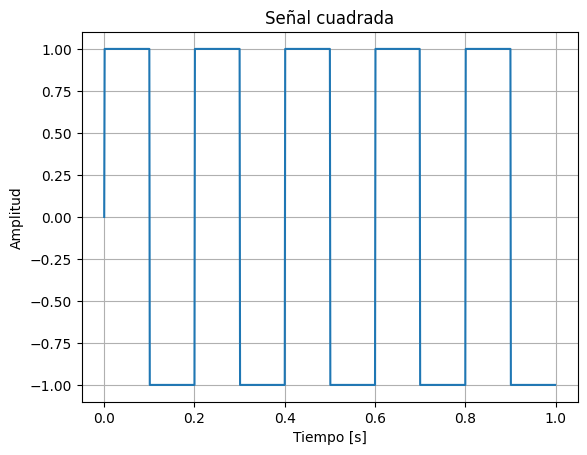

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_cuadrada(vmax, dc, ff, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    xx = dc + vmax * np.sign(np.sin(2*np.pi*ff*tt))
    return tt, xx

# Parámetros
fs = 1000
N = 1000

tt, xx = mi_funcion_cuadrada(1, 0, 5, N, fs)

plt.figure()
plt.plot(tt, xx)
plt.title("Señal cuadrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

---
## Conclusiones generales

- Se implementó `mi_funcion_sen`, generador de señales senoidales con 6 parámetros configurables, devolviendo vectores `tt` y `xx` de dimensión $N \times 1$.
- Los experimentos de aliasing confirman el **Teorema de Nyquist**: frecuencias superiores a $f_s/2$ producen señales indistinguibles de frecuencias menores, siendo este error **irrecuperable**.
-  Se implementó `mi_funcion_cuadrada`, haciendo un generador de señales distinto.